In [35]:
import tensorflow as tf
import os
import pandas as pd
import numpy as np

# Load the dataset


df = pd.read_csv("jena_climate_2009_2016.csv")

In [36]:
# Process the data
df = df[5::6]  # Downsample by taking every 6th value starting from the 5th
df.index = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
temp = df['T (degC)']

# Define function to create data windows
def df_to_X_y(df, window_size=5):
    df_as_np = df.to_numpy()
    X = []
    y = []
    for i in range(len(df_as_np) - window_size):
        row = [[a] for a in df_as_np[i:i + window_size]]
        X.append(row)
        label = df_as_np[i + window_size]
        y.append(label)
    return np.array(X), np.array(y)

WINDOW_SIZE = 5
X1, y1 = df_to_X_y(temp, WINDOW_SIZE)
X_train1, y_train1 = X1[:60000], y1[:60000]
X_val1, y_val1 = X1[60000:65000], y1[60000:65000]
X_test1, y_test1 = X1[65000:], y1[65000:]

# Define the custom loss function
def custom_loss(y_true, y_pred, lambda_=0.1 , lambda_2 = 2.0):
    # Prediction error (MSE)
    pred_error = tf.reduce_mean(tf.square(y_true - y_pred))
    
    # Smoothness penalty (absolute difference between consecutive predictions)
    smoothness_penalty = tf.reduce_mean(tf.abs(y_pred[1:] - y_pred[:-1]))
    
    # Combined loss
    return lambda_2*pred_error + lambda_ * smoothness_penalty

# Build the model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, LSTM, Dense
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam

model1 = Sequential([
    InputLayer((5, 1)),
    LSTM(64),
    Dense(8, activation='relu'),
    Dense(1, activation='linear')
])

model1.summary()

# Compile the model with the custom loss function
#cp1 = ModelCheckpoint('model1/', save_best_only=True)
model1.compile(loss=custom_loss, optimizer=Adam(learning_rate=0.0001), metrics=[tf.keras.metrics.RootMeanSquaredError()])

# Train the model
model1.fit(X_train1, y_train1, validation_data=(X_val1, y_val1), epochs=50)

# Load the best model
#from tensorflow.keras.models import load_model
#model1 = load_model('model1/', custom_objects={'custom_loss': custom_loss})

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │             520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,425 (68.07 KB)

 Trainable params: 17,425 (68.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 161.7899 - root_mean_squared_error: 8.7535 - val_loss: 2.6111 - val_root_mean_squared_error: 1.1291
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 6.9937 - root_mean_squared_error: 1.7370 - val_loss: 1.3414 - val_root_mean_squared_error: 0.7965
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 3.1037 - root_mean_squared_error: 1.0371 - val_loss: 1.1896 - val_root_mean_squared_error: 0.7461
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 2.5143 - root_mean_squared_error: 0.8814 - val_loss: 1.1259 - val_root_mean_squared_error: 0.7238
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 2.3464 - root_mean_squared_error: 0.8333 - val_loss: 1.1188 - val_root_mean_squared_error: 0.7213
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 2.2977 - root_mean_squared_error: 0.8183 - val_loss: 1.0929 - val_root_mean_squared_error: 0.7124
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━

In [37]:
train_predictions= model1.predict(X_train1)
val_predictions = model1.predict(X_val1)
test_predictions = model1.predict(X_test1)
test_predictions

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[14.560953 ],
       [13.382321 ],
       [13.07158  ],
       ...,
       [-1.6651543],
       [-3.1867936],
       [-3.0947075]], dtype=float32)

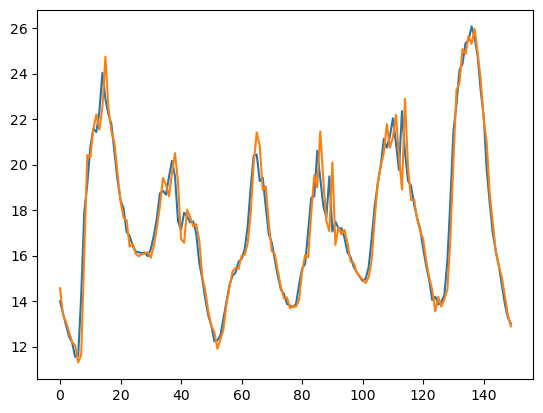

In [38]:
import matplotlib.pyplot as plt
plt.plot(y_test1[:150])
plt.plot(test_predictions[:150])

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
mae = mean_absolute_error(y_test1, test_predictions)
mse = mean_squared_error(y_test1, test_predictions)
rmse = np.sqrt(mse)

print("Test Set Performance:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Test Set Performance:
Mean Absolute Error (MAE): 0.5219640852134152
Mean Squared Error (MSE): 0.5848249378152807
Root Mean Squared Error (RMSE): 0.7647384767456654


In [40]:
from sklearn.metrics import r2_score

# Calculate the R-squared score
r2 = r2_score(y_test1, test_predictions)

print("R-squared (R2) Score:", r2)


R-squared (R2) Score: 0.9915997867443247


In [41]:
100*(0.9908755386352632 - 0.9911786654541112) 

-0.03031268188479208

In [42]:
# Save as HDF5 file
model1.save('my_model.h5')


In [43]:
# Load with custom loss function if needed
from tensorflow.keras.models import load_model
loaded_model = load_model('my_model.h5', custom_objects={'custom_loss': custom_loss})


In [44]:
from tensorflow.keras.models import load_model

loaded_model 


<Sequential name=sequential_1, built=True>

In [45]:
loaded_model.compile(loss=custom_loss, optimizer=Adam(learning_rate=0.0001), metrics=[tf.keras.metrics.RootMeanSquaredError()])
loaded_model.predict(X_test1)

159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


array([[14.560953 ],
       [13.382321 ],
       [13.07158  ],
       ...,
       [-1.6651543],
       [-3.1867936],
       [-3.0947075]], dtype=float32)

In [46]:
PREDS = model1.predict(X_test1)
PREDS

159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[14.560953 ],
       [13.382321 ],
       [13.07158  ],
       ...,
       [-1.6651543],
       [-3.1867936],
       [-3.0947075]], dtype=float32)

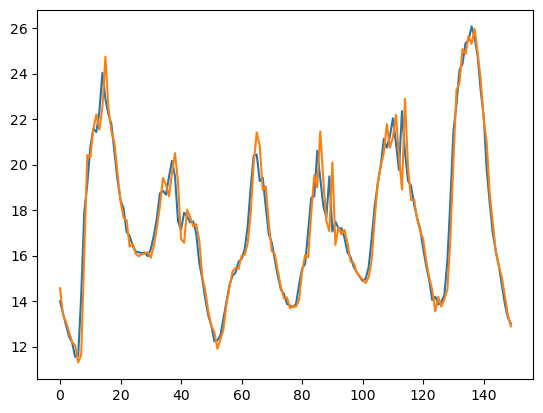

In [47]:
import matplotlib.pyplot as plt
plt.plot(y_test1[:150])
plt.plot(PREDS[:150])

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
mae = mean_absolute_error(y_test1, PREDS)
mse = mean_squared_error(y_test1, PREDS)
rmse = np.sqrt(mse)

print("Test Set Performance:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Test Set Performance:
Mean Absolute Error (MAE): 0.5219640852134152
Mean Squared Error (MSE): 0.5848249378152807
Root Mean Squared Error (RMSE): 0.7647384767456654
